# Bike lane expansion generator

In [2]:
#!pip install ipywidgets ipympl geodatasets contextily cartopy ipyleaflet sqlalchemy geopandas

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
# import os
# os.chdir("drive/My Drive/shapefiles_DC/")

In [8]:
%matplotlib widget

In [10]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
from ipyleaflet import Map, GeoData, basemaps, TileLayer, LayersControl, GeoJSON
from sqlalchemy import create_engine
import geopandas as gpd
import geodatasets
import contextily as cx
import geopandas as gpd
import networkx as nx
from shapely.geometry import LineString, Point

In [11]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.io.img_tiles import OSM


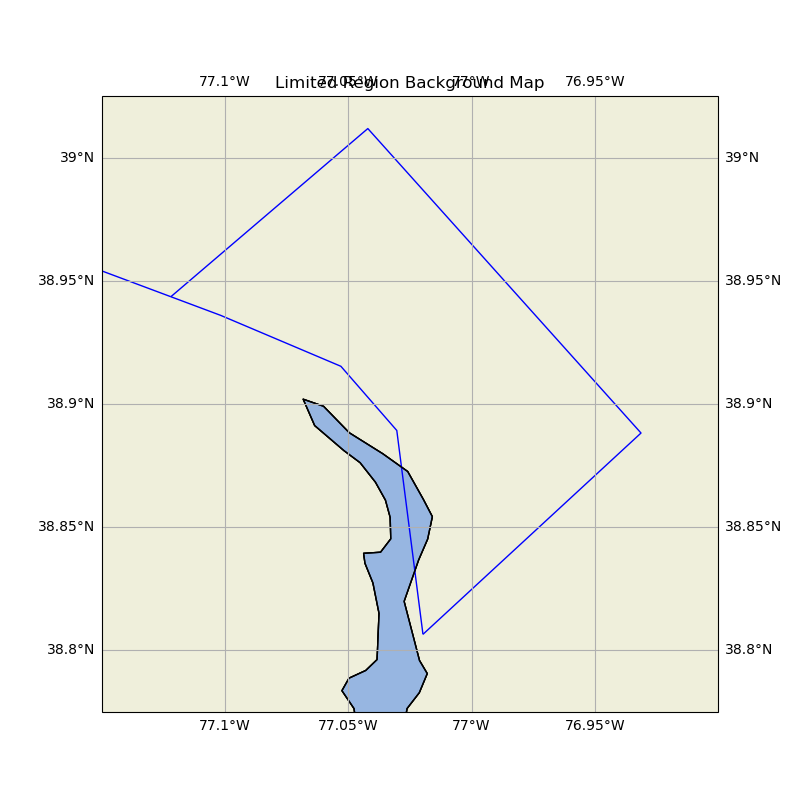

In [14]:

import cartopy.feature as cfeature

# Define the extent of the limited region
extent = [-77.15, -76.9, 38.775, 39.025]  # [lon_min, lon_max, lat_min, lat_max]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

states_provinces = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none')

# Set the extent of the map
ax.set_extent(extent)

# Add land and ocean background
ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN, edgecolor='black')
ax.add_feature(states_provinces, linestyle='-', edgecolor='blue', facecolor='none')


# Add coastlines
ax.coastlines(resolution='10m')

# Add gridlines
ax.gridlines(draw_labels=True)

plt.title('Limited Region Background Map')
plt.show()



## Get Datasets

In [17]:
def gdf_layer_gen(file_path, layer_name, args, shape, sample=False,filter_cond= None):

    gdf=gpd.read_file(file_path)
    if sample==True:
        gdf=gdf[filter_cond]

    for col in gdf.columns:
        #print(col,gdf[col].dtype)
        # if gdf[col].dtype=='Timestamp':
        if pandas.api.types.is_datetime64_any_dtype(gdf[col]):
            gdf[col]=gdf[col].astype(str)
    if shape=='point':
        layer=GeoData(geo_dataframe = gdf,
                       point_style=args,
                       name = layer_name)
    else:
        layer=GeoData(geo_dataframe = gdf,
                        style=args,
                       name = layer_name)
    return gdf,layer


In [19]:
#!ls

In [21]:
schools_args={'radius': 1, 'color': 'magenta', 'fillOpacity': 0.8, 'fillColor': 'magenta', 'weight': 3}
schools_gdf, schools_layer=gdf_layer_gen("DC_Public_Schools/DC_Public_Schools.shp",
                                           "Public_Schools_Locations", schools_args, 'point')

sch_zones_args={'radius': 1, 'color': 'pink', 'fillOpacity': 0.8, 'fillColor': 'pink', 'weight': 3}
sch_zones_gdf, sch_zones_layer=gdf_layer_gen("School_Attendance_Zones_(Middle_School)/School_Attendance_Zones_(Middle_School).shp",
                                           "Schools_Zones", sch_zones_args, 'area')

bike_lane_args={'radius': 1, 'color': 'brown', 'fillOpacity': 0.8, 'fillColor': 'brown', 'weight': 3}
bike_lanes_gdf,bike_lanes_layer=gdf_layer_gen("Bicycle_Lanes/Bicycle_Lanes.shp",
                                              "bike_lanes", bike_lane_args, 'line')

sidewalks_args={'radius': 1, 'color': 'orange', 'fillOpacity': 0.8, 'fillColor': 'orange', 'weight': 3}
sidewalks_gdf, sidewalks_layer=gdf_layer_gen("Sidewalks/Sidewalks.shp",
                                              "sidewalks", sidewalks_args, 'line')

roads_args={'radius': 1, 'color': 'purple', 'fillOpacity': 0.8, 'fillColor': 'purple', 'weight': 3}
roads_gdf, roads_layer=gdf_layer_gen("Roads/Roads.shp",
                                              "Roads", roads_args, 'line')

g_stores_args={'radius': 1, 'color': 'red', 'fillOpacity': 0.8, 'fillColor': 'red', 'weight': 3}
g_stores_gdf, g_stores_layer=gdf_layer_gen("Grocery_Store_Locations/Grocery_Store_Locations.shp",
                                           "Grocery_Store_Locations", g_stores_args, 'point')

traffic_args={'radius': 1, 'color': 'green', 'fillOpacity': 0.8, 'fillColor': 'green', 'weight': 3}
traffic_2021_gdf, traffic_2021_layer=gdf_layer_gen("2021_Traffic_Volume/2021_Traffic_Volume.shp",
                                                   "2021_Traffic_Volume", traffic_args, 'line')


LFAA_args={'radius': 1, 'color': 'yellow', 'fillOpacity': 0.8, 'fillColor': 'yellow', 'weight': 3}
LFAA_gdf, LFAA_layer=gdf_layer_gen("Low_Food_Access_Areas/Low_Food_Access_Areas.shp",
                                                   "Low_Food_Access_Areas", LFAA_args, 'line',
                                   # sample=True,filter_cond=(LFAA_gdf['PRTOVR185']==LFAA_gdf['PARTPOP2'])
                                  )

econ_filepath="ACS_5-Year_Economic_Characteristics_DC_Census_Tract/ACS_5-Year_Economic_Characteristics_DC_Census_Tract.shp"
Econ_args={'radius': 1, 'color': 'cyan', 'fillOpacity': 0.8, 'fillColor': 'cyan', 'weight': 3}
Econ_gdf, Econ_layer=gdf_layer_gen(econ_filepath,"Economic_Characteristics", Econ_args, 'line')



crashes_args={'radius': 1, 'color': 'magenta', 'fillOpacity': 0.8, 'fillColor': 'magenta', 'weight': 3}
crashes_gdf, crashes_layer=gdf_layer_gen("Crashes_in_DC/Crashes_in_DC.shp",
                                           "Crashes", crashes_args, 'point')


bike_trails_args={'radius': 1, 'color': 'black', 'fillOpacity': 0.8, 'fillColor': 'black', 'weight': 3}
bike_trails_gdf,bike_trails_layer=gdf_layer_gen("Bike_Trails/Bike_Trails.shp",
                                              "bike_trails", bike_trails_args, 'line')


census_2020_args={'radius': 1, 'color': 'gold', 'fillOpacity': 0.8, 'fillColor': 'gold', 'weight': 3}
census_2020_gdf, census_2020_layer=gdf_layer_gen("Census_Tracts_in_2020/Census_Tracts_in_2020.shp",
                                           "Census_2020", census_2020_args, 'point')


crashes_gdf=crashes_gdf.sjoin(census_2020_gdf, how='inner', predicate='covered_by')

## Feature Engineering
Focus on adding features to road segments.
- Use segments in traffic_2021_gdf
- Find length and traffic density
- Determine presense of bike lane (use sjoin)
- Determine accident count(density)
- Determine nearby points of interest (schools, stores)
- Population density





In [94]:
traffic_2021_gdf['ROUTEID'].value_counts()

/var/folders/dq/80cd69hx4ms79xlvwds2rxm40000gn/T/ipykernel_37197/354371152.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  traffic_2021_gdf['ROUTEID'].value_counts()[0]


399

(array([6558., 3240., 3446., 4023., 2972., 3436., 2340., 1552.,  275.,
         343.]),
 array([   0. ,  265.3,  530.6,  795.9, 1061.2, 1326.5, 1591.8, 1857.1,
        2122.4, 2387.7, 2653. ]),
 <BarContainer object of 10 artists>)

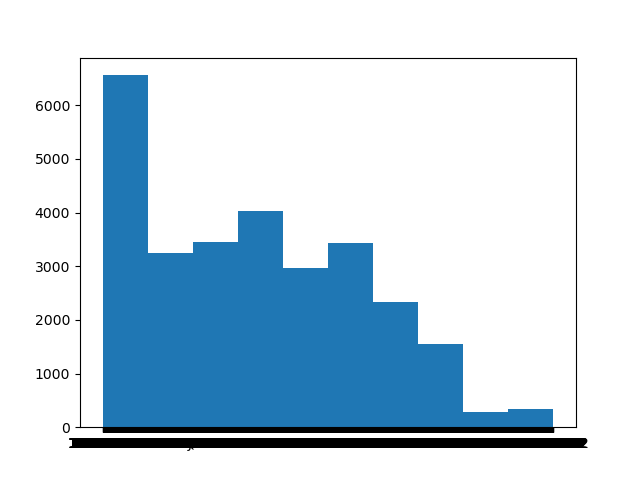

In [90]:
plt.close('all')
plt.hist(traffic_2021_gdf['ROUTEID'])

In [24]:
census_2020_gdf['PDENSITY']=census_2020_gdf['P0010001']/census_2020_gdf['ALAND']
census_2020_gdf['ALAND']

0       849376
1       600992
2       725975
3       415173
4       698895
        ...   
201    2381015
202     152450
203     498122
204    5718693
205    6514228
Name: ALAND, Length: 206, dtype: int32

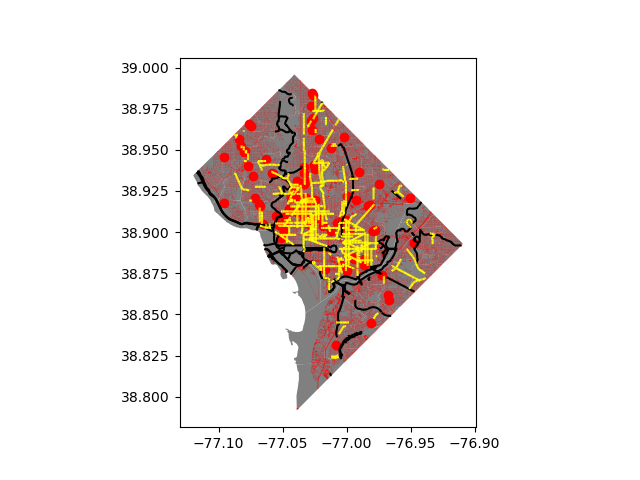

In [26]:
plt.close('all')
# base=census_2020_gdf.plot(column='PDENSITY', legend=False)
base=census_2020_gdf.plot(color='grey')
bike_trails_gdf.plot(ax=base,color='black')
bike_lanes_gdf.plot(ax=base,color='yellow')
g_stores_gdf.plot(ax=base,color='red')
roads_gdf.plot(ax=base,color='red')
# crashes_gdf.plot(ax=base,markersize=0.1,color='orange' )
plt.show()



In [72]:

census_2020_gdf['crash_count'] = 0

# Iterate over each polygon in 'A'
for index, polygon in census_2020_gdf.iterrows():
    # Check if the polygon has any points from 'B' within it
    points_within_polygon = crashes_gdf[crashes_gdf.geometry.within(polygon.geometry)]
    # Get the count of points within the polygon
    point_count = len(points_within_polygon)
    # Assign the count to the 'point_count' column in 'A'
    census_2020_gdf.at[index, 'crash_count'] = point_count

# Now 'A' contains a new column 'point_count' with the count of points from 'B' covered by each polygon in 'A'


In [74]:
census_2020_gdf['crash_count'].max()


9013

In [60]:
crashes_gdf[crashes_gdf.geometry.within((census_2020_gdf['geometry'])[0])]#(census_2020_gdf['geometry'])[0].plot()

,OBJECTID_left,CRIMEID,CCN,REPORTDATE,ROUTEID,MEASURE,OFFSET,STREETSEGI,ROADWAYSEG,FROMDATE,...,P0050003,P0050004,P0050005,P0050006,P0050007,P0050008,P0050009,P0050010,SHAPEAREA,SHAPELEN
168,249742837,23695453,11084587,2011-06-15,11034972,1335.65,0.07,9497.0,19103.0,2011-06-15,...,0,0,0,0,32,0,0,32,0,0
195,249742864,23562747,11004561,2011-01-11,11024502,2026.49,40.51,-9.0,27351.0,2011-01-10,...,0,0,0,0,32,0,0,32,0,0
869,249743538,24040288,12079709,2012-06-09,11040042,3615.64,45.83,-9.0,27444.0,2012-06-09,...,0,0,0,0,32,0,0,32,0,0
1349,249744018,24085072,12094226,2012-07-06,11033472,1219.08,0.00,9091.0,21347.0,2012-07-06,...,0,0,0,0,32,0,0,32,0,0
1546,249744215,24094582,12097137,2012-07-12,11040042,4472.68,0.00,11017.0,16499.0,2012-07-12,...,0,0,0,0,32,0,0,32,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306989,250049658,55026969469,24046094,2024-03-28,11011052,1597.31,27.78,NaN,NaN,2024-03-27,...,0,0,0,0,32,0,0,32,0,0
307000,250049669,55028089397,24046180,2024-03-28,11001602,5859.87,41.77,NaN,NaN,2024-03-27,...,0,0,0,0,32,0,0,32,0,0
307012,250049681,55037451012,24046357,2024-03-28,11056812,1676.49,19.28,NaN,NaN,2024-03-28,...,0,0,0,0,32,0,0,32,0,0
307014,250049683,55037982932,24046376,2024-03-28,11001402,7231.40,25.11,NaN,NaN,2024-03-28,...,0,0,0,0,32,0,0,32,0,0


### find shortest path example
- make traffic grid ( use traffic_2021_gdf)
- add interest points to grid
- add new edges
- find shortest path
- plot found path against grid

In [96]:
def find_shortest_path(start_point =Point(-77.00, 38.8328,0.0),
                       end_point =Point(-76.947, 38.893,0.0),
                       input_gdf=traffic_2021_gdf
                      ):
    # Example of finding the shortest path
    # start_point =Point(-77.00, 38.8328,0.0) # list(G.nodes)[100000]#(1,1)#(-76.93884, 38.87493)  # Coordinates of the start node
    # end_point =Point(-76.947, 38.893,0.0)  # list(G.nodes)[50000]#(10,10)#(-76.93307, 38.88152)    # Coordinates of the end node
    # start_point, end_point



    # Convert the linestrings into a graph
    G = nx.Graph()
    A_exploded = input_gdf.explode(index_parts=True)
    # Add edges from the linestrings
    
    fail_c=0
    
    for idx, row in A_exploded.iterrows():
        line = row.geometry
        # print(line)
        if line.geom_type!= 'LineString':
            line=line.boundary
        # print(line)
        
        try:
            nodes = list(line.coords)
            # print(nodes)
        except:
            fail_c+=1
            
            #print('error', fail_c, line)
        for i in range(len(nodes)-1):
            # print(i)
            node1 = Point(nodes[i])
            node2 = Point(nodes[i+1])
            distance = line.length
            G.add_edge(node1, node2, weight=distance)
            
    # print(fail_c)

    # Connect start and end points to the nearest nodes in the graph
    nearest_start_node = min(G.nodes(), key=lambda node:start_point.distance(node))
    nearest_end_node = min(G.nodes(), key=lambda node: end_point.distance(node))
    nearest_start_node_index = list(G.nodes()).index(nearest_start_node)
    nearest_start_end_index = list(G.nodes()).index(nearest_end_node)
    nearest_start_node_index, nearest_start_end_index

    G.add_node(start_point)
    G.add_node(end_point)

    G.add_edge(start_point, nearest_start_node, weight=start_point.distance(nearest_start_node))
    G.add_edge(end_point, nearest_end_node, weight=end_point.distance(nearest_end_node))



    # Find the shortest path
    # shortest_path = nx.shortest_path(G, source=list(G.nodes)[202248], target=list(G.nodes)[202249] , weight='weight')
    shortest_path = nx.shortest_path(G, source=start_point, target=end_point , weight='weight')
    # shortest_path

    shortest_path_edges =[Point(p.x, p.y) for p in shortest_path]#shortest_path# list(zip(shortest_path, shortest_path[1:]))
    
    noedge_c=0
    for edge in shortest_path_edges:
        try:
            edge.z
            noedge_c+=1
            # print(edge)
        except:
            continue
    print(f'non edge count= {noedge_c}')
    shortest_path_line = LineString(shortest_path_edges)
    
    return shortest_path_line

non edge count= 0


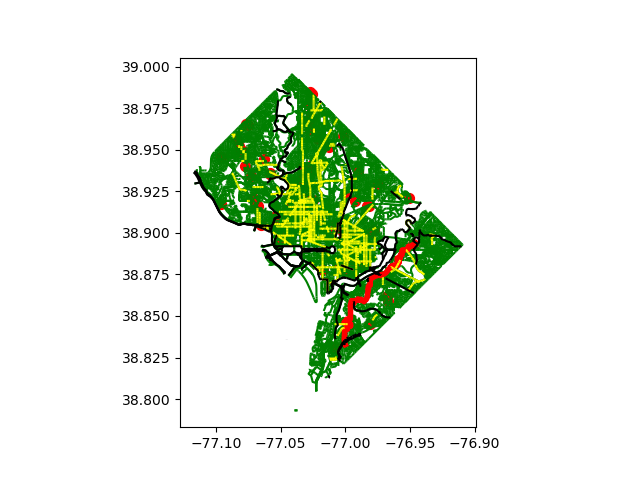

In [98]:
plt.close('all')

shortest_path_line=find_shortest_path(input_gdf=roads_gdf)

# Plot the grid and the shortest path
ax = traffic_2021_gdf.plot(color='green')
g_stores_gdf.plot(ax=ax,color='red', markersize=50)
# Plot shortest pathg_stores_gdf.plot(ax=ax,color='red')
plt.plot(*shortest_path_line.xy, color='red', linewidth=4)
bike_lanes_gdf.plot(ax=ax,color='yellow')
bike_trails_gdf.plot(ax=ax,color='black')

plt.show()

In [ ]:
crashes_gdf.geometry.isna().value_counts()

In [ ]:
traffic_2021_gdf['SHAPELEN']=traffic_2021_gdf['geometry'].to_crs(epsg= 3857).length
traffic_2021_gdf['SHAPELEN']

In [ ]:

traffic_2021_gdf['AADTDEN']=traffic_2021_gdf['AADT']/traffic_2021_gdf['SHAPELEN']


In [ ]:
plt.close('all')
traffic_2021_gdf[traffic_2021_gdf['AADTDEN']<1e3].hist(column=['AADTDEN'], bins=10)

In [ ]:
#find closest enc objects to signature
join_df= traffic_2021_gdf.to_crs(epsg= 3857).sjoin(bike_lanes_gdf.to_crs(epsg= 3857), how="inner", predicate='contains')
join_df=join_df.to_crs(epsg=4326)
join_df

In [ ]:
bike_lanes_gdf.to_crs(epsg= 3857).sjoin(traffic_2021_gdf.to_crs(epsg= 3857), how="inner", predicate='contains')


In [ ]:
# fig, ax = plt.subplots()
base=census_2020_gdf.plot(color='grey')
LFAA_gdf.plot(ax=base,column='PERCENTUND',legend=True)

g_stores_gdf.plot(ax=base, markersize=3,color='red')
schools_gdf.plot(ax=base, markersize=5,color='purple')
bike_trails_gdf.plot(ax=base,color='gold')
bike_lanes_gdf.plot(ax=base,color='yellow')

Econ_gdf.plot(column='DP03_0001E',legend=True)

In [ ]:
from cartopy.io.img_tiles import OSM
plt.close('all')

osm_tiles = OSM()

plt.figure(figsize=(8, 8))

# Use the tile's projection for the underlying map.
base = plt.axes(projection=osm_tiles.crs, zorder=1)
LFAA_gdf.plot(ax=base, column='PERCENTUND', legend=True, zorder=2)

# Specify a region of interest.
base.set_extent([-77.15, -76.9, 38.775, 39.025], ccrs.PlateCarree())

# Add the tiles at zoom level 12.
base.add_image(osm_tiles, 12)

# Add coastlines
# base.coastlines('10m')

# Assuming LFAA_gdf is a GeoDataFrame containing some spatial data
# You need to import the GeoDataFrame first and ensure it's defined.
# Here's an example assuming LFAA_gdf is defined:

plt.show()

In [ ]:
roads_gdf.plot()

In [ ]:
traffic_2021_gdf[traffic_2021_gdf['AADTDEN']>0.1e4].plot(column='AADTDEN', legend=True)

In [ ]:
# -77.08618 38.95706
def interactive_map():
    center = [38.9,-77]
    zoom = 11
    m=Map(basemap=basemaps.OpenStreetMap.Mapnik, center=center, zoom=zoom)

    m.add_layer(Econ_layer)
    m.add_layer(LFAA_layer)
    m.add_layer(sch_zones_layer)
    m.add_layer(traffic_2021_layer)
    # m.add_layer(roads_layer)
    m.add_layer(sidewalks_layer)
    m.add_layer(bike_lanes_layer)
    m.add_layer(g_stores_layer)
    m.add_layer(schools_layer)



    m.add_control(LayersControl())

    display(m)

In [ ]:
# interactive_map()